In [1]:
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd

In [2]:
def create_graphs_with_attributes(edgelist_filepath,attributes_filepath):
    graph=nx.read_edgelist(edgelist_filepath,nodetype=int)
    attributes=pd.read_csv(attributes_filepath,index_col=['node'])
    att_values = {a:{'role':b[0],'community':b[1]} for a,b in enumerate(attributes.values)}
    nx.set_node_attributes(graph,att_values)
    return graph


def create_train_test(graph):
    X_train,Y_train,X_test,Y_test=[],[],[],[]
    for node, data in graph.nodes(data=True):
        if data['role'] in ['Administrator','Instructor']:
            X_train.append(node)
            Y_train.append(data['role']=='Administrator')
        elif data['role'] =='Member':
            X_test.append(node)
            Y_test.append(data['community']=='Administrator')
    return np.asarray(X_train),np.asarray(Y_train),np.asarray(X_test),np.asarray(Y_test)



def create_features(graph): # create input features, concatenation of identity matrix and shortest paths to targets
    A = nx.to_numpy_matrix(graph)
    X_1 = torch.eye(A.shape[0]) # identity matrix
    X_2 = torch.zeros((A.shape[0], 2)) # shortest path to the targets as 2nd input feature
    node_distance_instructor = nx.shortest_path_length(graph, target=33)
    node_distance_administrator = nx.shortest_path_length(graph, target=0)

    for node in graph.nodes():
        X_2[node][0] = node_distance_administrator[node]
        X_2[node][1] = node_distance_instructor[node]

    return torch.cat((X_1,X_2),dim=1)    

## Model: Graph Convolutional Networks

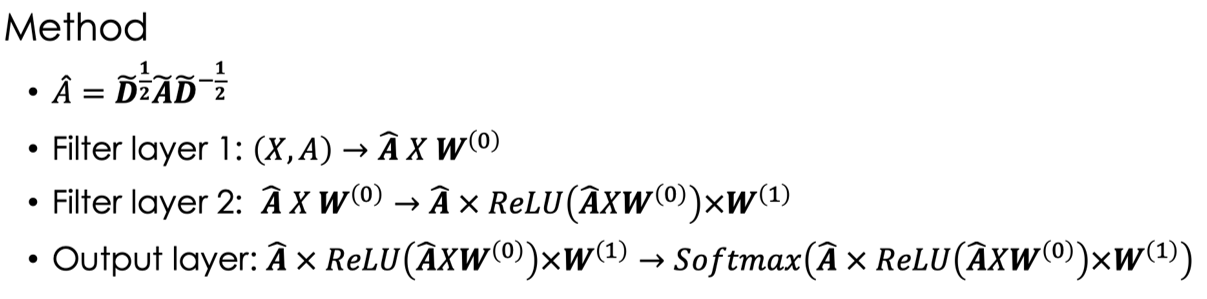

Epoch 000 | Loss: 0.6920
Epoch 010 | Loss: 0.6914
Epoch 020 | Loss: 0.6909
Epoch 030 | Loss: 0.6904
Epoch 040 | Loss: 0.6896
Epoch 050 | Loss: 0.6888
Epoch 060 | Loss: 0.6878
Epoch 070 | Loss: 0.6868
Epoch 080 | Loss: 0.6854
Epoch 090 | Loss: 0.6840
Epoch 100 | Loss: 0.6825
Epoch 110 | Loss: 0.6808
Epoch 120 | Loss: 0.6791
Epoch 130 | Loss: 0.6772
Epoch 140 | Loss: 0.6753
Epoch 150 | Loss: 0.6733
Epoch 160 | Loss: 0.6717
Epoch 170 | Loss: 0.6696
Epoch 180 | Loss: 0.6679
Epoch 190 | Loss: 0.6661
Epoch 200 | Loss: 0.6647
Epoch 210 | Loss: 0.6631
Epoch 220 | Loss: 0.6620
Epoch 230 | Loss: 0.6605
Epoch 240 | Loss: 0.6596
Epoch 249 | Loss: 0.6585
Validation loss: 0.6129, Accuracy: 81.82%
              precision    recall  f1-score   support

           0     0.8000    0.8000    0.8000         5
           1     0.8333    0.8333    0.8333         6

    accuracy                         0.8182        11
   macro avg     0.8167    0.8167    0.8167        11
weighted avg     0.8182    0.8182   

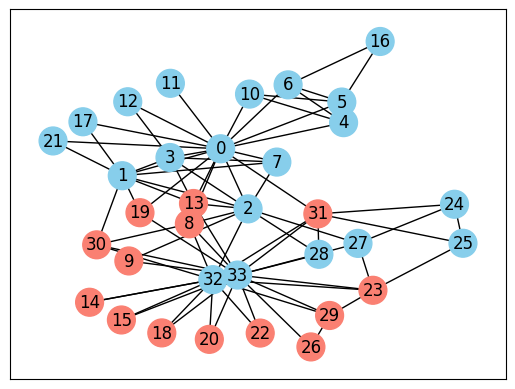

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import networkx as nx
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


def create_graphs_with_attributes(edge_file, attr_file):
    G = nx.read_edgelist(edge_file, nodetype=int)
    df = pd.read_csv(attr_file)

    node_ids = df.iloc[:, 0].astype(int).values
    label_col = df.columns[-1]
    label_series = df[label_col]

    if label_series.dtype == object:
        label_series, _ = pd.factorize(label_series)

    labels = label_series.astype(int)

    feature_df = df.iloc[:, 1:-1].copy()

    for col in feature_df.columns:
        if feature_df[col].dtype == object:
            feature_df[col] = pd.factorize(feature_df[col])[0]

    features = torch.tensor(feature_df.values, dtype=torch.float32)

    for i, node in enumerate(node_ids):
        if node in G.nodes:
            G.nodes[node]['features'] = features[i]
            G.nodes[node]['label'] = int(labels[i])

    return G





def create_features(G):
    return torch.stack([G.nodes[n]['features'] for n in G.nodes()])


def create_labels(G):
    return np.array([G.nodes[n]['label'] for n in G.nodes()])


def create_train_test(G, train_ratio=0.7, seed=42):
    np.random.seed(seed)
    nodes = np.array(list(G.nodes()))
    labels = create_labels(G)

    idx = np.arange(len(nodes))
    np.random.shuffle(idx)

    train_size = int(train_ratio * len(nodes))
    train_idx = idx[:train_size]
    test_idx = idx[train_size:]

    return train_idx, labels[train_idx], test_idx, labels[test_idx]


class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super(GraphConvolution, self).__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, A, X):
        I = torch.eye(A.size(0))
        A_hat = A + I
        D_hat = torch.diag(torch.pow(A_hat.sum(1), -0.5))
        A_norm = D_hat @ A_hat @ D_hat

        return self.linear(A_norm @ X)


class GCN(nn.Module):
    def __init__(self, inputs_shape, outputs_shape, n_classes, activation='Relu'):
        super(GCN, self).__init__()
        self.gc1 = GraphConvolution(inputs_shape, outputs_shape)
        self.gc2 = GraphConvolution(outputs_shape, n_classes)
        self.activation = F.relu if activation.lower() == 'relu' else torch.tanh

    def forward(self, A, X):
        out = self.gc1(A, X)
        out = self.activation(out)
        out = self.gc2(A, out)
        return out

class Trainer():
    def __init__(self, model, optimizer, loss_function, epochs):
        self.model = model
        self.optimizer = optimizer
        self.loss_function = loss_function
        self.epochs = epochs

    def train(self, A, X, X_train, Y_train):
        y_train = torch.from_numpy(Y_train).type(torch.LongTensor)
        tot_loss = 0.0
        all_preds = []

        for t in range(self.epochs):
            self.model.train()
            y_pred = self.model(A, X)

            loss = self.loss_function(y_pred[X_train], y_train)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            tot_loss += loss.item()
            all_preds.append(y_pred.detach())

            if t % 10 == 0 or t == self.epochs - 1:
                print(f"Epoch {t:03d} | Loss: {loss.item():.4f}")

        self.all_preds = all_preds

    def test(self, A, X, X_test, Y_test):
        self.model.eval()
        y_test = torch.from_numpy(Y_test).type(torch.LongTensor)
        y_pred = self.all_preds[-1]
        loss_test = self.loss_function(y_pred[X_test], y_test)
        preds = y_pred[X_test].argmax(dim=1)
        acc = (preds == y_test).float().mean().item()
        print(f"Validation loss: {loss_test.item():.4f}, Accuracy: {acc*100:.2f}%")
        print(classification_report(y_test.numpy(), preds.numpy(), digits=4))

    def visualize_classification(self, graph, Y_true):
        last_epoch = self.all_preds[-1].detach().numpy()
        predicted_class = np.argmax(last_epoch, axis=-1)
        color = np.where(predicted_class == 0, 'skyblue', 'salmon')
        pos = nx.kamada_kawai_layout(graph)
        nx.draw_networkx(graph, pos, node_color=color, with_labels=True, node_size=400)
        plt.show()

if __name__ == "__main__":
    # Tạo graph
    graph = create_graphs_with_attributes('lab2_edgelist.txt', 'lab2_attributes.csv')
    A = torch.tensor(nx.to_numpy_array(graph), dtype=torch.float32)
    X = create_features(graph)

    X_train, Y_train, X_test, Y_test = create_train_test(graph)

    model = GCN(inputs_shape=X.shape[1], outputs_shape=4, n_classes=2, activation='Relu')

    trainer = Trainer(
        model=model,
        optimizer=optim.Adam(model.parameters(), lr=0.01),
        loss_function=F.cross_entropy,
        epochs=250
    )

    trainer.train(A, X, X_train, Y_train)
    trainer.test(A, X, X_test, Y_test)
    trainer.visualize_classification(graph, Y_test)
